# Exploratory Data Analysis: Student Performance

This notebook examines the raw student-performance dataset before feature engineering and model training. The analysis focuses on dataset structure, data quality, score distribution, relationships between study conditions and exam performance, and patterns that should inform modeling decisions.

The raw dataset is loaded from `artifacts/data/raw/dataset.csv`. All conclusions are descriptive and should not be interpreted as causal effects.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebook" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "artifacts" / "data" / "raw" / "dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset path: C:\Users\LENOVO\codes\student-performance-indicator\artifacts\data\raw\dataset.csv
Shape: 6,607 rows x 20 columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 1. Dataset structure and data quality

This first checks establish the schema, data types, missingness, duplicate count, and cardinality of categorical variables. These checks are important because ingestion and downstream preprocessing depend on exact column names and valid target values.

In [2]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
}).sort_values(["missing_count", "unique_values"], ascending=[False, True])

print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Total missing values: {df.isna().sum().sum():,}")
schema

Duplicate rows: 0
Total missing values: 235


,dtype,missing_count,missing_pct,unique_values
Parental_Education_Level,str,90,1.36,3
Teacher_Quality,str,78,1.18,3
Distance_from_Home,str,67,1.01,3
Extracurricular_Activities,str,0,0.00,2
Internet_Access,str,0,0.00,2
School_Type,str,0,0.00,2
Learning_Disabilities,str,0,0.00,2
Gender,str,0,0.00,2
Parental_Involvement,str,0,0.00,3
Access_to_Resources,str,0,0.00,3


- Target value is integer

In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist() # captures both int and float
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"{len(numeric_columns)} Numeric columns:", numeric_columns)
print(f"{len(categorical_columns)} Categorical columns:", categorical_columns)

cardinality = pd.DataFrame({
    "unique_values": df[categorical_columns].nunique().sort_values(),
    "levels": [
        ", ".join(map(str, sorted(df[column].dropna().unique())))
        for column in df[categorical_columns].nunique().sort_values().index
    ],
})
cardinality

7 Numeric columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
13 Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


,unique_values,levels
Extracurricular_Activities,2,"No, Yes"
Internet_Access,2,"No, Yes"
School_Type,2,"Private, Public"
Learning_Disabilities,2,"No, Yes"
Gender,2,"Female, Male"
Access_to_Resources,3,"High, Low, Medium"
Motivation_Level,3,"High, Low, Medium"
Parental_Involvement,3,"High, Low, Medium"
Teacher_Quality,3,"High, Low, Medium"
Family_Income,3,"High, Low, Medium"


## 2. Numeric feature distributions

Numeric variables describe study behavior, attendance, prior achievement, support received, and the final exam score. Histograms and boxplots reveal scale, spread, skew, and possible outliers.

In [4]:
numeric_summary = df[numeric_columns].describe().T
numeric_summary["missing"] = df[numeric_columns].isna().sum()
numeric_summary["skewness"] = df[numeric_columns].skew().round(2)
numeric_summary["kurtosis"] = df[numeric_columns].kurtosis().round(2)
numeric_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,missing,skewness,kurtosis
Hours_Studied,"6,607.00",19.98,5.99,1.00,16.00,20.00,24.00,44.00,0,0.01,0.02
Attendance,"6,607.00",79.98,11.55,60.00,70.00,80.00,90.00,100.00,0,0.01,-1.19
Sleep_Hours,"6,607.00",7.03,1.47,4.00,6.00,7.00,8.00,10.00,0,-0.02,-0.50
Previous_Scores,"6,607.00",75.07,14.40,50.00,63.00,75.00,88.00,100.00,0,-0.00,-1.19
Tutoring_Sessions,"6,607.00",1.49,1.23,0.00,1.00,1.00,2.00,8.00,0,0.82,0.64
Physical_Activity,"6,607.00",2.97,1.03,0.00,2.00,3.00,4.00,6.00,0,-0.03,-0.06
Exam_Score,"6,607.00",67.24,3.89,55.00,65.00,67.00,69.00,101.00,0,1.64,10.58


- Exam_Score is highly skewed and kurt. Model must put this into consideration, so as not to make wrong predictions for non represented layer of scores.

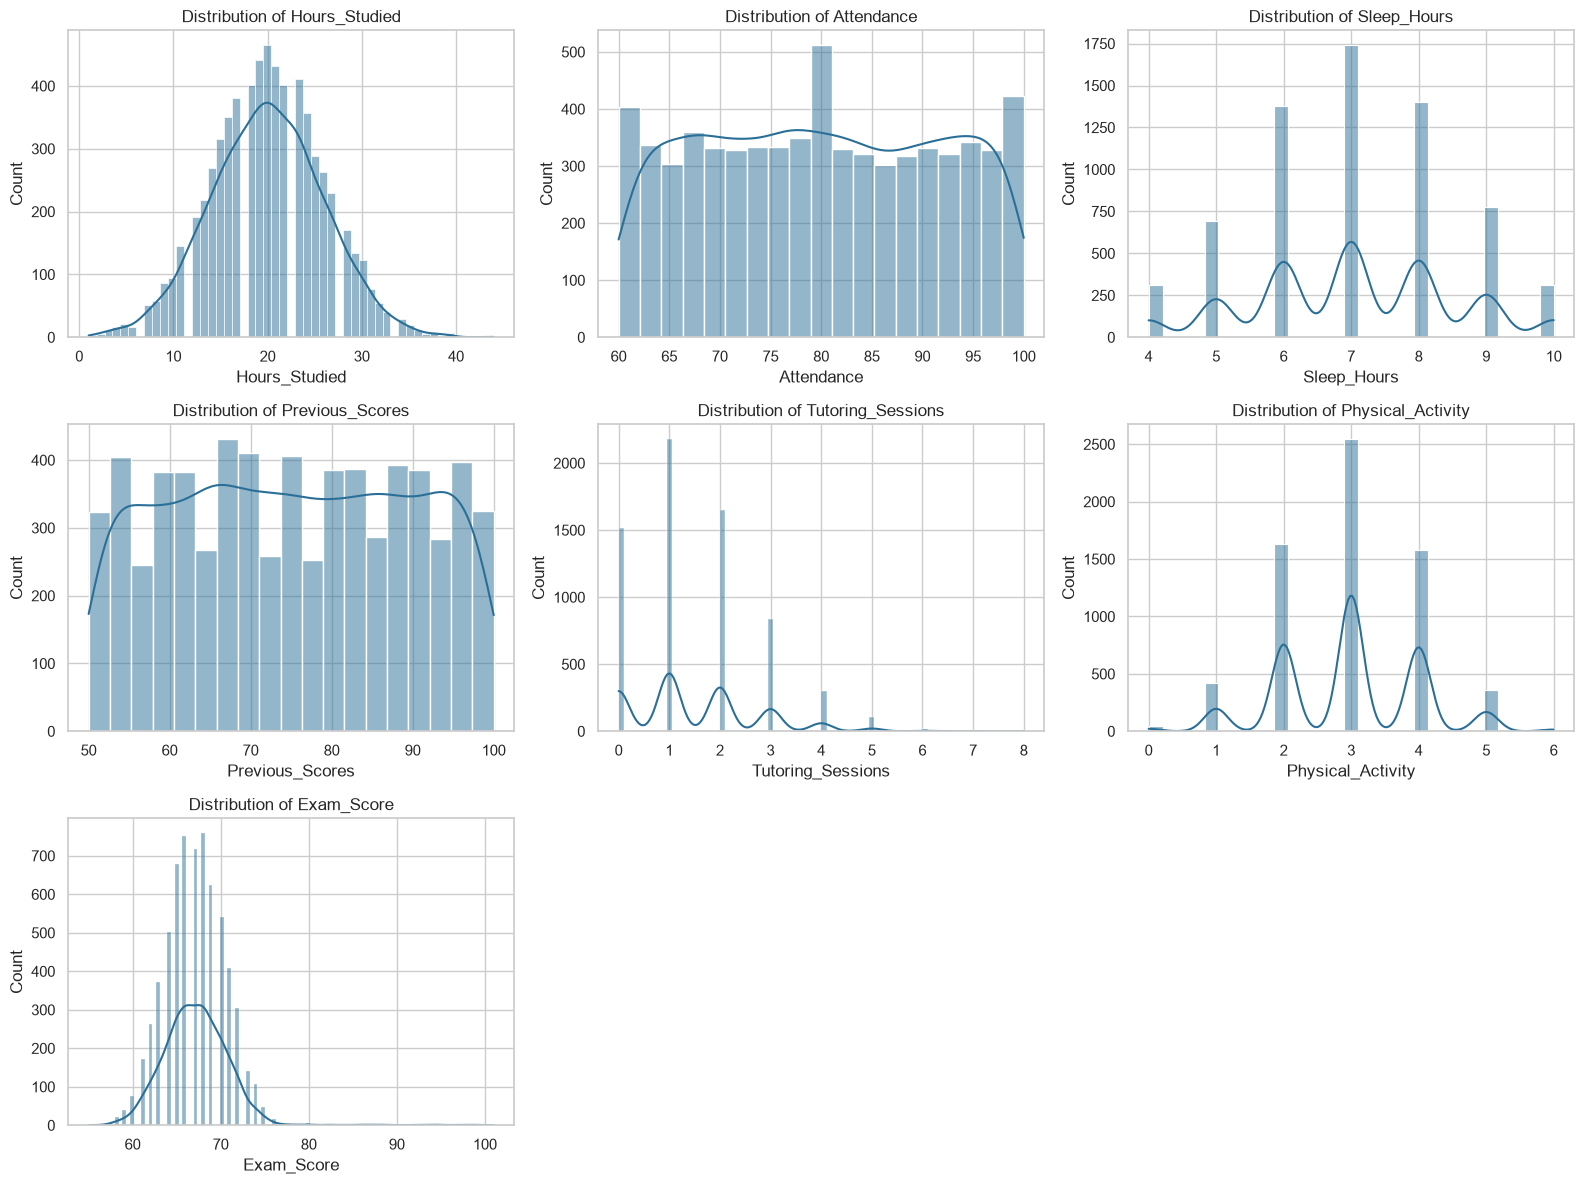

In [5]:
plot_columns = numeric_columns
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for axis, column in zip(axes, plot_columns, strict=False):
    sns.histplot(data=df, x=column, kde=True, ax=axis, color="#2a6f97")
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column)

for axis in axes[len(plot_columns):]:
    axis.set_visible(False)

plt.tight_layout()
plt.show()

## 3. Target variable: Exam_Score

The target is concentrated around the high 60s. This section quantifies its range and checks whether extreme values deserve investigation before modeling.

In [6]:
target = "Exam_Score"
target_summary = df[target].describe().to_frame("value")
target_summary.loc["missing"] = df[target].isna().sum()
target_summary.loc["unique"] = df[target].nunique()
target_summary.round(2)

,value
count,"6,607.00"
mean,67.24
std,3.89
min,55.00
25%,65.00
50%,67.00
75%,69.00
max,101.00
missing,0.00
unique,45.00


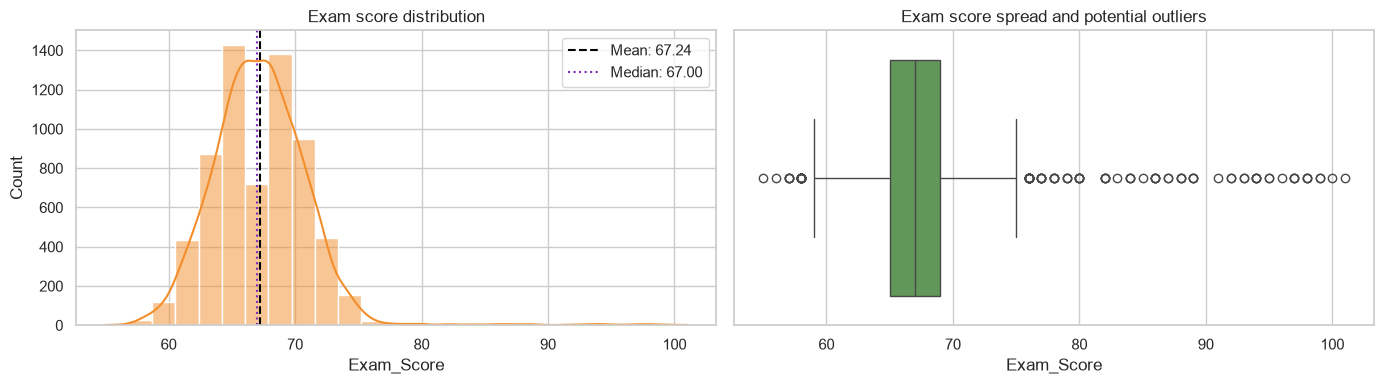

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x=target, bins=25, kde=True, ax=axes[0], color="#f28e2b")
axes[0].axvline(df[target].mean(), color="black", linestyle="--", label=f"Mean: {df[target].mean():.2f}")
axes[0].axvline(df[target].median(), color="#7b2cbf", linestyle=":", label=f"Median: {df[target].median():.2f}")
axes[0].set_title("Exam score distribution")
axes[0].legend()

sns.boxplot(data=df, x=target, ax=axes[1], color="#59a14f")
axes[1].set_title("Exam score spread and potential outliers")
plt.tight_layout()
plt.show()

## 4. Categorical features and group comparisons

Categorical variables capture student context and access to support. The charts below show both category balance and the distribution of exam scores within each group. Group means are descriptive; they do not establish that a category causes a score difference.

In [8]:
categorical_counts = {
    column: df[column].value_counts(dropna=False).rename("count").to_frame().assign(
        percentage=lambda table: table["count"] / len(df) * 100
    )
    for column in categorical_columns
}

for column, counts in categorical_counts.items():
    print(f"\n{column}")
    display(counts.round(2))


Parental_Involvement


,count,percentage
Parental_Involvement,,
Medium,3362,50.89
High,1908,28.88
Low,1337,20.24



Access_to_Resources


,count,percentage
Access_to_Resources,,
Medium,3319,50.23
High,1975,29.89
Low,1313,19.87



Extracurricular_Activities


...

,count,percentage
Parental_Education_Level,,
High School,3223,48.78
College,1989,30.10
Postgraduate,1305,19.75
NaN,90,1.36



Distance_from_Home


,count,percentage
Distance_from_Home,,
Near,3884,58.79
Moderate,1998,30.24
Far,658,9.96
NaN,67,1.01



Gender


,count,percentage
Gender,,
Male,3814,57.73
Female,2793,42.27


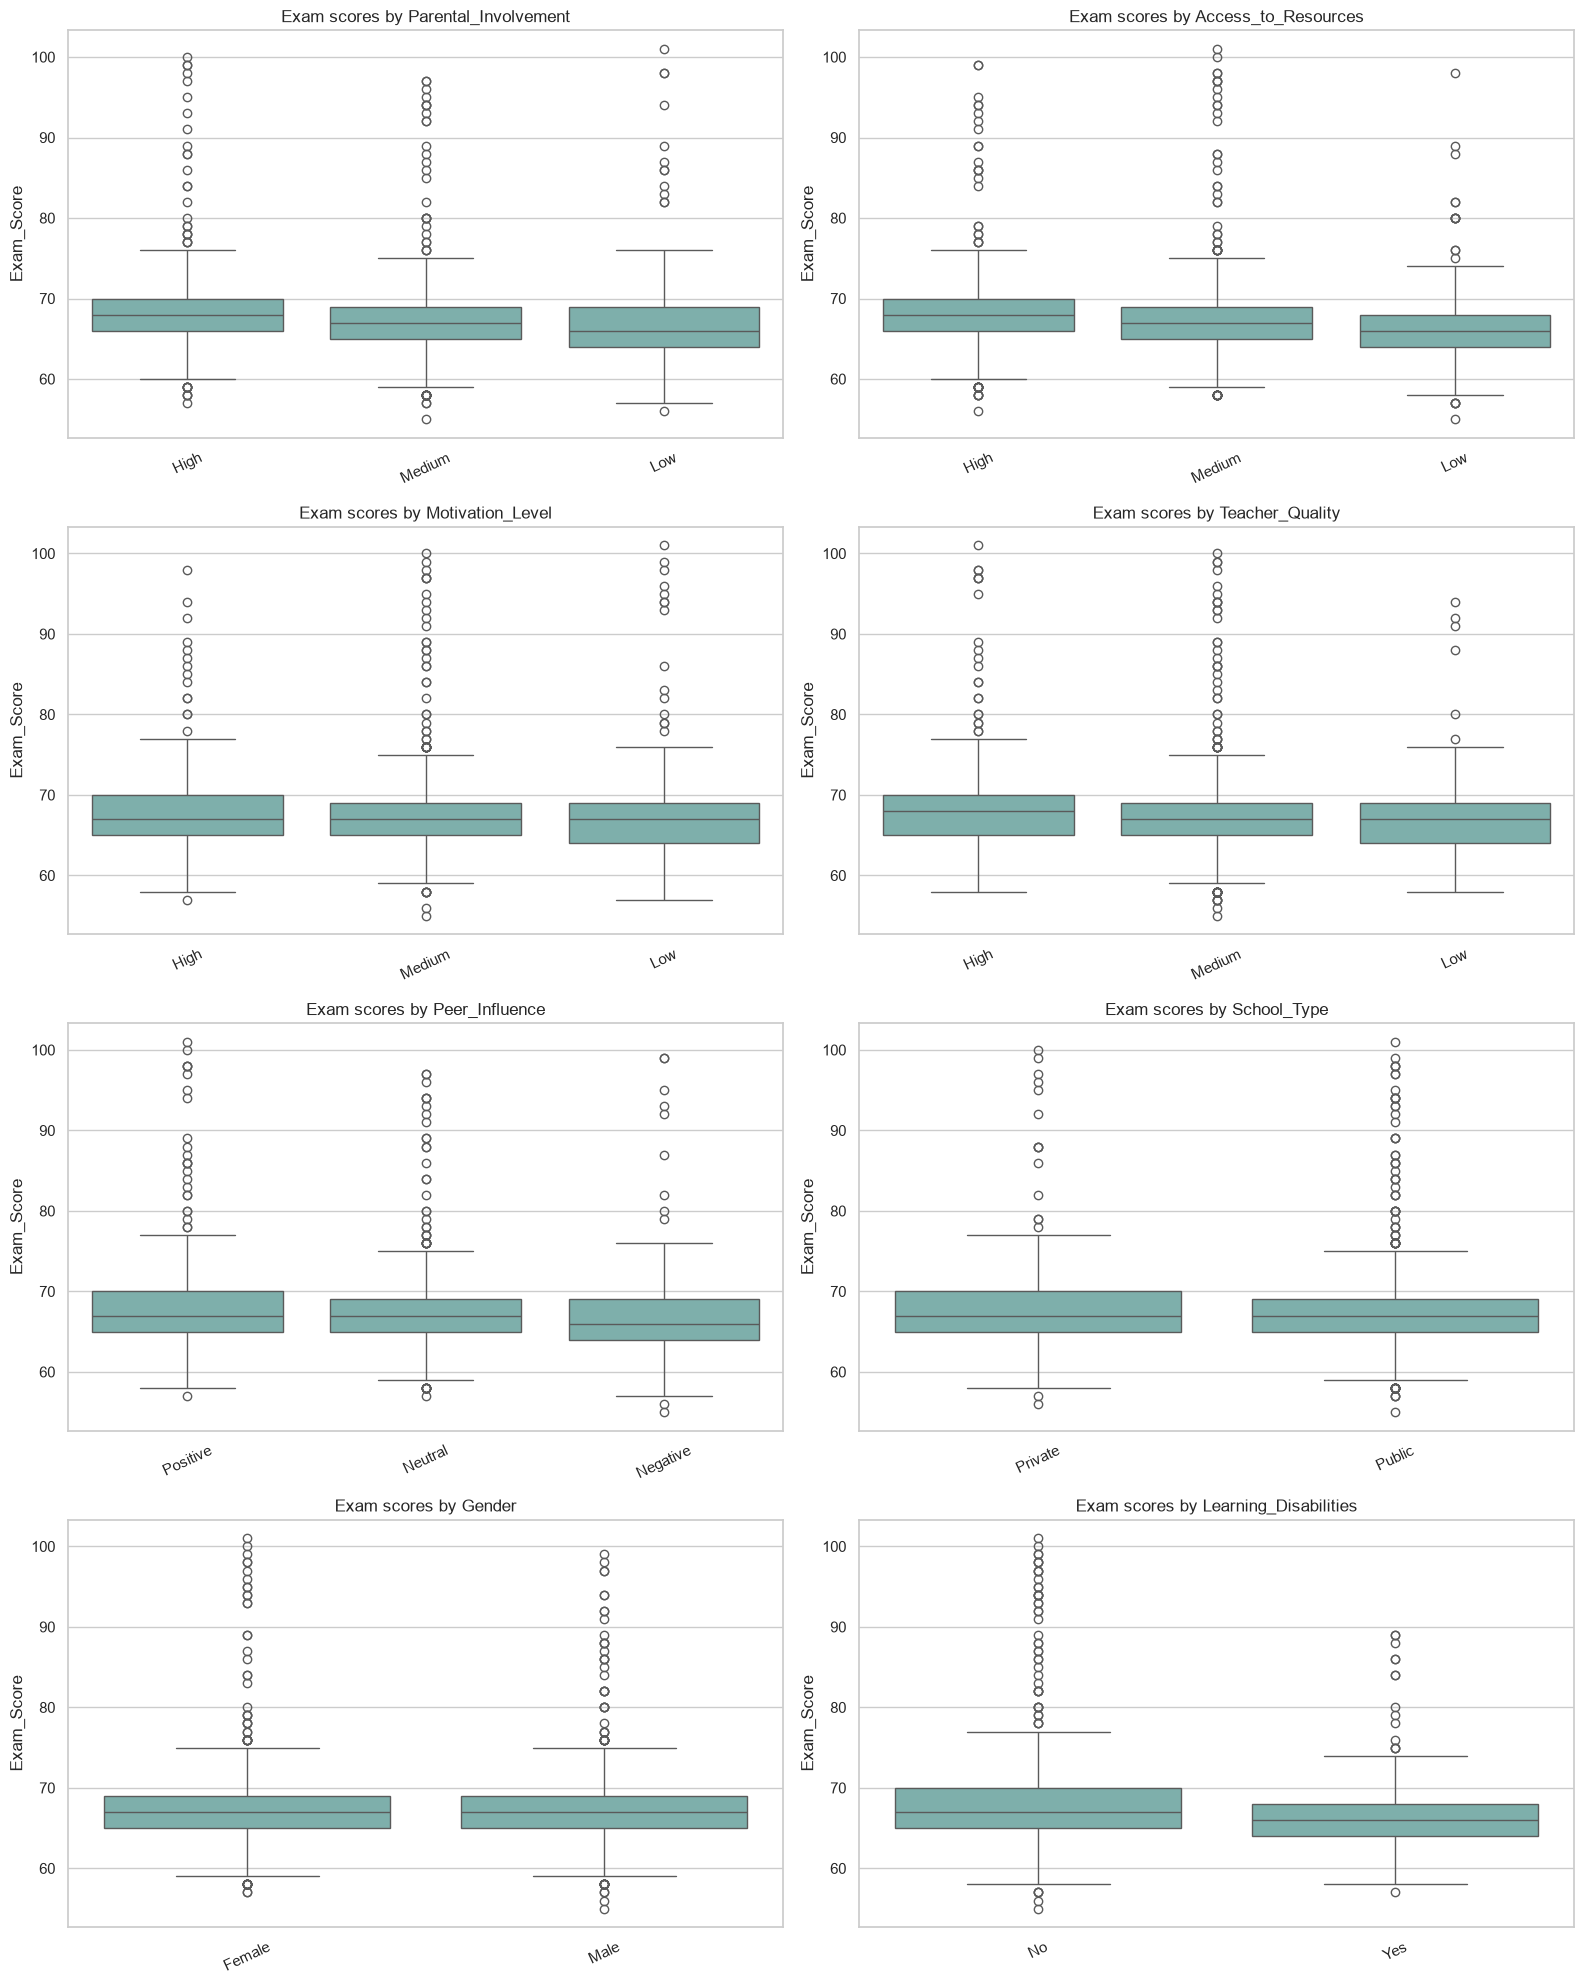

In [9]:
comparison_columns = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Teacher_Quality",
    "Peer_Influence",
    "School_Type",
    "Gender",
    "Learning_Disabilities",
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
for axis, column in zip(axes.ravel(), comparison_columns, strict=False):
    order = df.groupby(column)[target].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x=column, y=target, order=order, ax=axis, color="#76b7b2")
    axis.set_title(f"Exam scores by {column}")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [10]:
group_summary = []
for column in categorical_columns:
    grouped = (
        df.groupby(column, dropna=False)[target]
        .agg(count="size", mean="mean", median="median", std="std")
        .sort_values("mean", ascending=False)
    )
    grouped.insert(0, "feature", column)
    grouped.insert(1, "category", grouped.index.astype(str))
    group_summary.append(grouped.reset_index(drop=True))

group_summary = pd.concat(group_summary, ignore_index=True)
group_summary["mean"] = group_summary["mean"].round(2)
group_summary["median"] = group_summary["median"].round(2)
group_summary["std"] = group_summary["std"].round(2)
group_summary

,feature,category,count,mean,median,std
0,Parental_Involvement,High,1908,68.09,68.00,3.95
1,Parental_Involvement,Medium,3362,67.10,67.00,3.73
2,Parental_Involvement,Low,1337,66.36,66.00,3.97
3,Access_to_Resources,High,1975,68.09,68.00,3.95
4,Access_to_Resources,Medium,3319,67.13,67.00,3.87
5,Access_to_Resources,Low,1313,66.20,66.00,3.56
6,Extracurricular_Activities,Yes,3938,67.44,67.00,3.94
7,Extracurricular_Activities,No,2669,66.93,67.00,3.79
8,Motivation_Level,High,1319,67.70,67.00,3.88
9,Motivation_Level,Medium,3351,67.33,67.00,3.83


## 5. Numeric relationships with exam performance

Correlation helps identify linear relationships worth considering during feature engineering. It is a screening tool, not proof of causality, and it can miss nonlinear relationships.

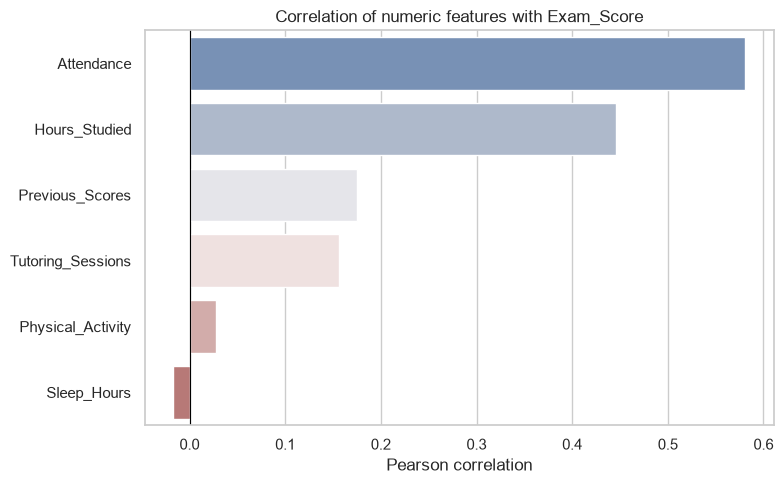

,correlation
Attendance,0.58
Hours_Studied,0.45
Previous_Scores,0.17
Tutoring_Sessions,0.16
Physical_Activity,0.03
Sleep_Hours,-0.02


In [13]:
correlations = (
    df[numeric_columns]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=np.abs, ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=correlations.values, y=correlations.index, palette="vlag", hue=correlations.index, legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of numeric features with Exam_Score")
plt.xlabel("Pearson correlation")
plt.ylabel("")
plt.tight_layout()
plt.show()

correlations.to_frame("correlation").round(3)

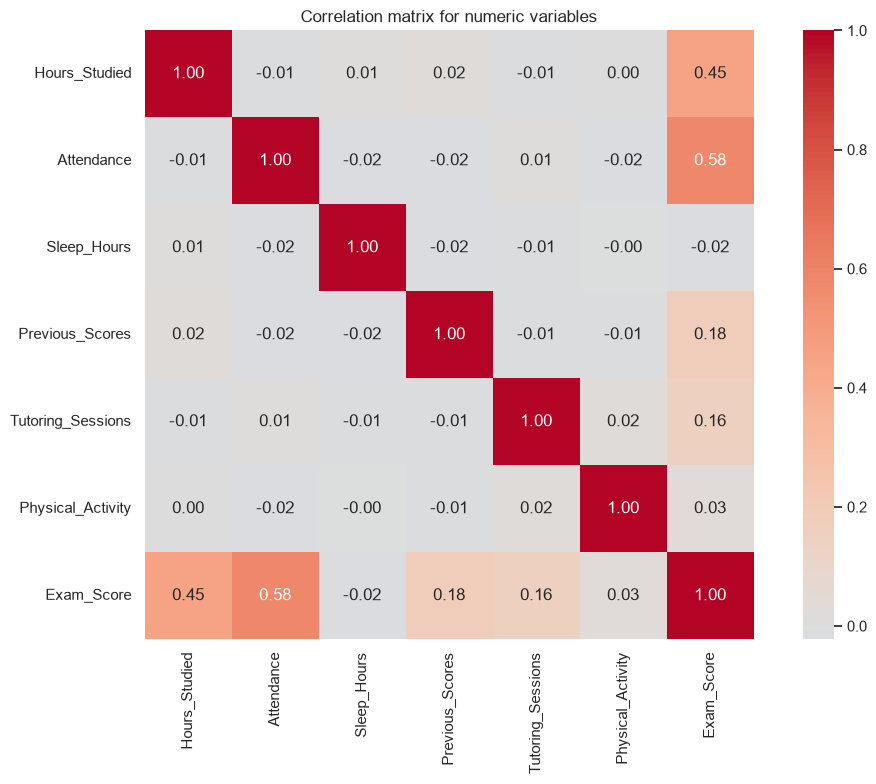

In [14]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    df[numeric_columns].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Correlation matrix for numeric variables")
plt.tight_layout()
plt.show()

## 6. Key numeric interactions

Attendance and study time are the strongest numeric candidates in the initial screening. The scatterplots below show their individual relationships with exam score and use color to expose whether the pattern is broadly consistent across the observed range.

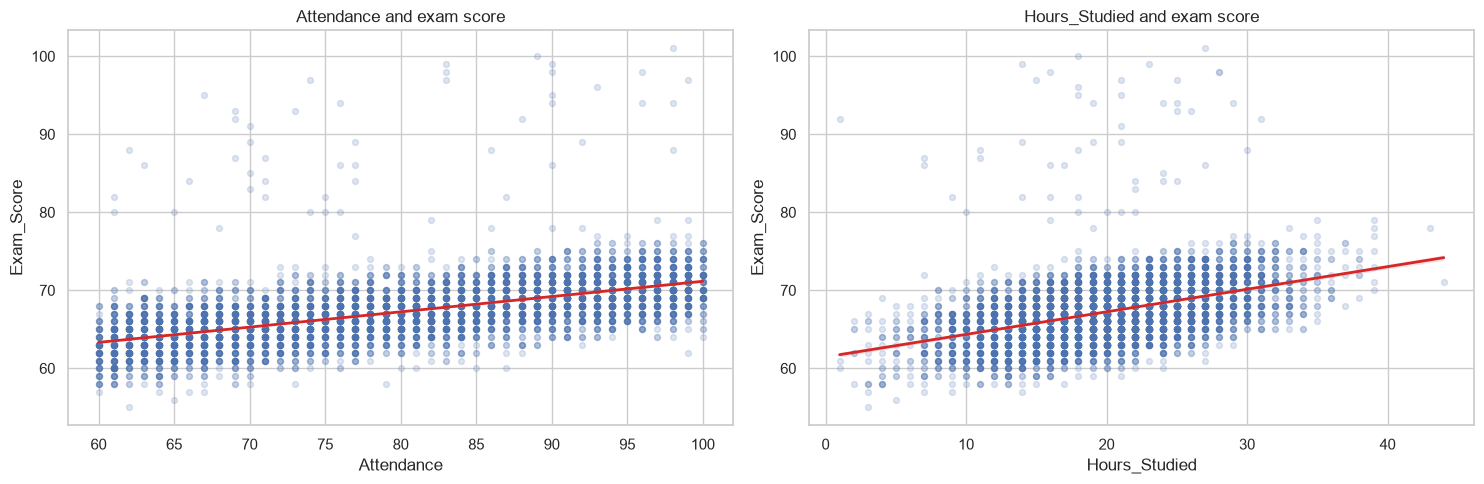

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, feature in zip(axes, ["Attendance", "Hours_Studied"], strict=False):
    sns.regplot(
        data=df,
        x=feature,
        y=target,
        scatter_kws={"alpha": 0.18, "s": 18},
        line_kws={"color": "#d62728", "linewidth": 2},
        ax=axis,
    )
    axis.set_title(f"{feature} and exam score")
    axis.set_xlabel(feature)
    axis.set_ylabel(target)

plt.tight_layout()
plt.show()

In [16]:
def mean_score_by(column):
    return df.groupby(column, dropna=False)[target].mean().sort_values(ascending=False)

print(f"Rows: {len(df):,}")
print(f"Missing values: {int(df.isna().sum().sum()):,}")
print(f"Duplicate rows: {int(df.duplicated().sum()):,}")
print(f"Exam score mean: {df[target].mean():.2f}")
print(f"Exam score median: {df[target].median():.2f}")
print(f"Exam score range: {df[target].min():.0f} to {df[target].max():.0f}")
print(f"Strongest numeric correlation: {correlations.index[0]} ({correlations.iloc[0]:.3f})")
print(f"Weakest numeric correlation: {correlations.index[-1]} ({correlations.iloc[-1]:.3f})")

for feature in ["Parental_Involvement", "Access_to_Resources", "Motivation_Level", "Tutoring_Sessions"]:
    print(f"\nMean Exam_Score by {feature}:")
    display(mean_score_by(feature).round(2).to_frame("mean_exam_score"))

Rows: 6,607
Missing values: 235
Duplicate rows: 0
Exam score mean: 67.24
Exam score median: 67.00
Exam score range: 55 to 101
Strongest numeric correlation: Attendance (0.581)
Weakest numeric correlation: Sleep_Hours (-0.017)

Mean Exam_Score by Parental_Involvement:


,mean_exam_score
Parental_Involvement,
High,68.09
Medium,67.10
Low,66.36



Mean Exam_Score by Access_to_Resources:


,mean_exam_score
Access_to_Resources,
High,68.09
Medium,67.13
Low,66.20



Mean Exam_Score by Motivation_Level:


,mean_exam_score
Motivation_Level,
High,67.70
Medium,67.33
Low,66.75



Mean Exam_Score by Tutoring_Sessions:


,mean_exam_score
Tutoring_Sessions,
6,71.67
7,69.86
5,69.07
8,69.00
4,68.23
3,67.89
2,67.57
1,66.98
0,66.49


## 7. Findings and modeling considerations

- The dataset contains a large sample of student records and a mixture of numeric and categorical predictors.
- Missingness should be handled explicitly before modeling; this notebook reports the affected columns without silently imputing them.
- Attendance and hours studied show the clearest linear associations with `Exam_Score` among the numeric variables.
- Prior scores and tutoring sessions show weaker positive associations, while sleep hours and physical activity appear comparatively weak in a linear screen.
- Category-level score differences are useful for feature exploration, but group sizes and confounding should be considered before interpreting them.
- The target distribution should be checked for unusual values, especially because the observed maximum is above the typical central range.
- Any predictive model should use a train/test split and evaluate generalization with metrics appropriate for numeric regression, such as MAE, RMSE, and $R^2$.

This EDA provides a baseline understanding of the raw data. The next stages should preserve the target column exactly as it appears in the dataset (`Exam_Score`) or apply a deliberate, documented schema normalization step before ingestion.